# Fantasy Football Hierarchical Bayesian Inference

## Imports

In [1]:
import math
import nfldb
import matplotlib.pyplot as plt
from pylab import rcParams
%matplotlib inline
%config InlineBackend.figure_format = 'png'
import seaborn as sns
import numpy as np
import pandas as pd
import theano.tensor as tt
import pymc3 as pm
from scipy import optimize
from IPython.core.debugger import Tracer

## Data Import and Munging

### nfldb
Create data base with metrics for the 2015 regular season with nfldb

In [2]:
from nfldbim import nfldbim
season_year = 2015
season_type = 'Regular'
weeks = range(0, 18)
df, teams, num_teams = nfldbim(season_year, season_type, weeks)

### Make test data set
drop week 17 data to be used for cross validation

In [3]:
df_test = df[df['week']==17]

## Modeling
### Priors

In [4]:
model = pm.Model()
with pm.Model() as model:
    # global model parameters
    home       = pm.Normal('home',      0, tau=.0001)
    tau_att    = pm.Gamma('tau_att',   .1, .1)
    tau_def    = pm.Gamma('tau_def',   .1, .1)
    intercept  = pm.Normal('intercept', 0, tau=.0001)
    #team-specific parameters
    atts_star  = pm.Normal('atts_star',
                           mu    = 0,
                           tau   = tau_att,
                           shape = num_teams)
    defs_star  = pm.Normal('defs_star',
                           mu    = 0,
                           tau   = tau_def,
                           shape = num_teams)

### Constraints

In [5]:
with model:
    atts       = pm.Deterministic('atts', atts_star - tt.mean(atts_star))
    defs       = pm.Deterministic('defs', defs_star - tt.mean(defs_star))
    home_theta = tt.exp(intercept + home + atts[df.i_home.values] + defs[df.i_away.values])
    away_theta = tt.exp(intercept + atts[df.i_away.values] + defs[df.i_home.values])

### Update beleifs with observations

In [6]:
# this will be the metric we're considering here
#metric = 'passing_yds'
metric = 'score'

# metric for home and away 
home_metric = 'home_'+metric
away_metric = 'away_'+metric

In [7]:
K = 1 # TODO: let K be a function of the metric. 10 is good for yards, 1 is good for score...
with model:
    # likelihood of observed data
    home_score = pm.Poisson('home_score',
                      mu=home_theta,
                      observed=df[home_metric].values/K)
    away_score = pm.Poisson('away_score',
                      mu=away_theta,
                      observed=df[away_metric].values/K)
    

## Sampling

/Users/edgar/Library/Environments/ff/lib/python2.7/site-packages/pymc3/tuning/starting.py:91: UserWarning: In future versions, set the optimization algorithm with a string. For example, use `method="L-BFGS-B"` instead of `fmin=sp.optimize.fmin_l_bfgs_b"`.
  warnings.warn('In future versions, set the optimization algorithm with a string. '
logp = -2,095.9:  16%|█▋        | 8210/50000 [00:05<00:28, 1462.29it/s]

Optimization terminated successfully.
         Current function value: 2095.939911
         Iterations: 11
         Function evaluations: 8213


100%|██████████| 20500/20500 [00:45<00:00, 453.56it/s]


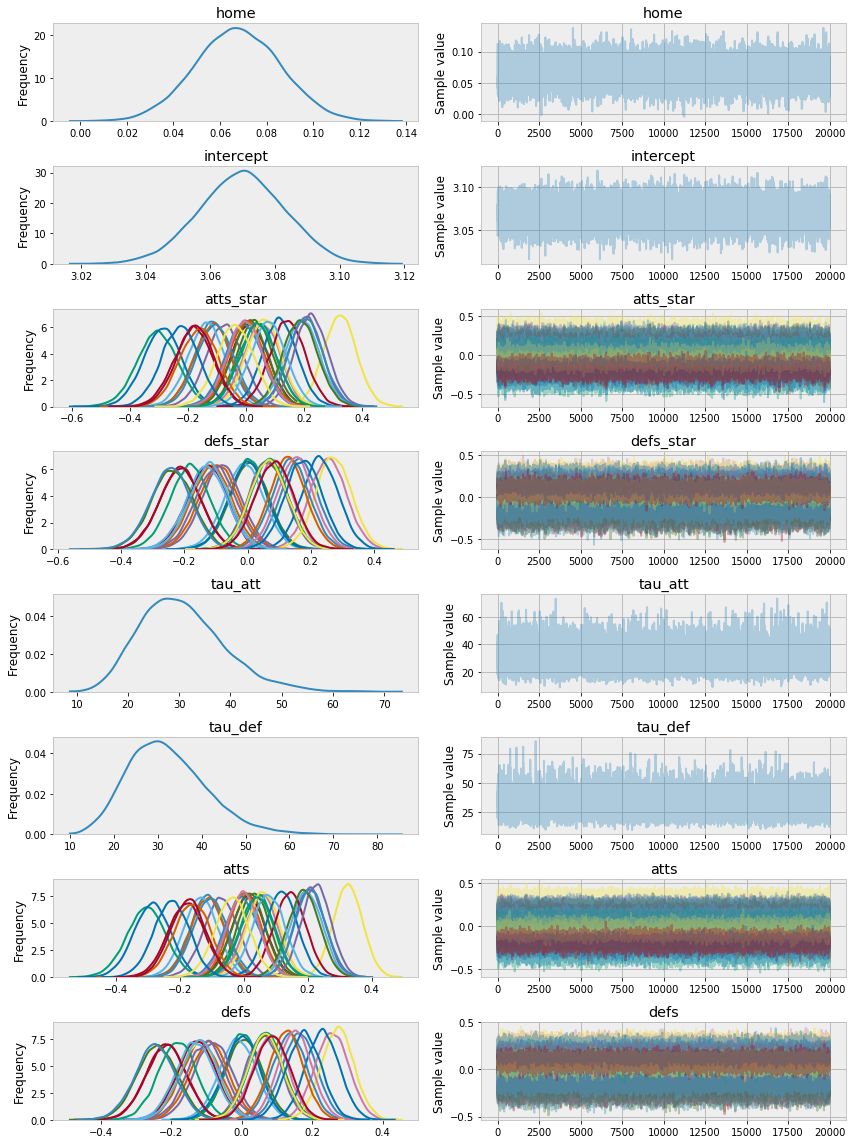

In [8]:
with model:
    start = pm.find_MAP(fmin=optimize.fmin_powell, maxeval=50000)
    #start = pm.find_MAP()
    step = pm.NUTS()
    trace = pm.sample(20000,step, start=start)
pm.traceplot(trace);

## Results
### Convergence

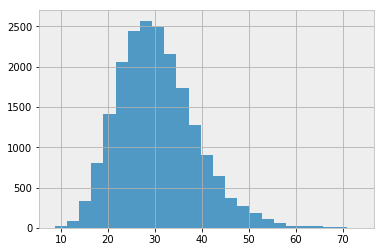

In [9]:
plt.hist(trace['tau_att'], histtype='stepfilled', bins=25, alpha=0.85);

### Confidence Intervals

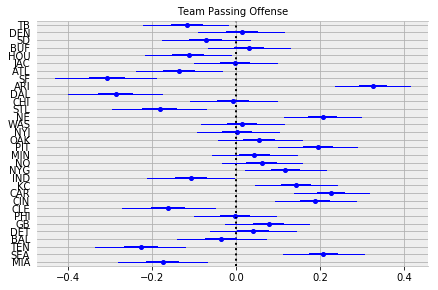

In [10]:
pm.forestplot(trace, varnames=['atts'], ylabels=teams['team'], main="Team Passing Offense")

### Defense strength

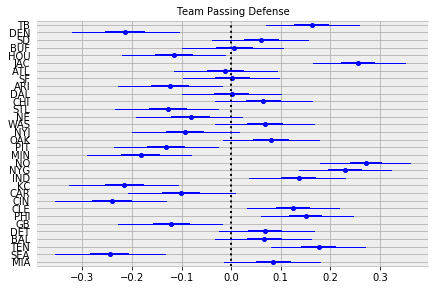

In [11]:
pm.forestplot(trace, varnames=['defs'], ylabels=teams['team'], main="Team Passing Defense")

# Simulation
## Define simulation

In [12]:
def simulate_team_seasons(games, n):
    dfs = []
    for i in range(n):
        season = simulate_team_season(games)
        t = create_team_season_table(season)
        t['iteration'] = i
        dfs.append(t)
    return pd.concat(dfs, ignore_index=True)
    
def simulate_team_season(games):
    num_samples = trace['atts'].shape[0]
    draw = np.random.randint(0, num_samples)
    atts_draw = pd.DataFrame({'att': trace['atts'][draw, :],})
    defs_draw = pd.DataFrame({'def': trace['defs'][draw, :],})
    home_draw = trace['home'][draw]
    intercept_draw = trace['intercept'][draw]
    season = games.copy()
    season = pd.merge(season, atts_draw, left_on='i_home', right_index=True)
    season = pd.merge(season, defs_draw, left_on='i_home', right_index=True)
    season = season.rename(columns = {'att': 'att_home', 'def': 'def_home'})
    season = pd.merge(season, atts_draw, left_on='i_away', right_index=True)
    season = pd.merge(season, defs_draw, left_on='i_away', right_index=True)
    season = season.rename(columns = {'att': 'att_away', 'def': 'def_away'})
    season['home'] = home_draw
    season['intercept'] = intercept_draw
    season['home_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                 x['home'] +
                                                 x['att_home'] +
                                                 x['def_away']), axis=1)
    season['away_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                 x['att_away'] +
                                                 x['def_home']), axis=1)
    season[home_metric] = season.apply(lambda x: K*np.random.poisson(x['home_theta']), axis=1)
    season[away_metric] = season.apply(lambda x: K*np.random.poisson(x['away_theta']), axis=1)
    return season
def create_team_season_table(season):
    home = season[['home_team', home_metric]].rename(columns = {'home_team':'team', home_metric:metric})
    # metric for away team
    away = season[['away_team', away_metric]].rename(columns = {'away_team':'team', away_metric:metric})
    
    return pd.concat( [home, away], axis=0)


## Simulation

/Users/edgar/Library/Environments/ff/lib/python2.7/site-packages/ipykernel_launcher.py:15: FutureWarning: by argument to sort_index is deprecated, please use .sort_values(by=...)
  from ipykernel import kernelapp as app


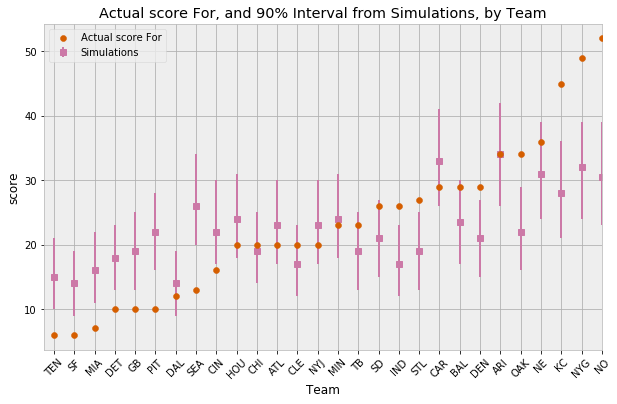

In [90]:
# conduct simulation
df_test = df[df['week']==8]
num_simulations = 1000
simuls = simulate_team_seasons(df_test, num_simulations)
simuls.set_index('team', inplace=True)
df_observed = create_team_season_table(df_test)
g = simuls.groupby('team')
season_hdis = pd.DataFrame({'metric_lower': g[metric].quantile(.1),
                            'metric_median': g[metric].median(),
                            'metric_upper': g[metric].quantile(.9)
})
season_hdis = pd.merge(season_hdis, df_observed, left_index=True, right_on='team')
season_hdis['relative_upper'] = season_hdis.metric_upper - season_hdis.metric_median
season_hdis['relative_lower'] = season_hdis.metric_median - season_hdis.metric_lower
season_hdis = season_hdis.sort_index(by=metric)
season_hdis = season_hdis.reset_index()
season_hdis['x'] = season_hdis.index + .5

fig, axs = plt.subplots(figsize=(10,6))
axs.scatter(season_hdis.x, season_hdis[metric], c=sns.palettes.color_palette()[4], zorder = 10, label='Actual '+metric+' For')
axs.errorbar(season_hdis.x, season_hdis.metric_median,
                yerr=(season_hdis[['relative_lower', 'relative_upper']].values).T,
                fmt='s', c=sns.palettes.color_palette()[5], label='Simulations')
axs.set_title('Actual '+metric+' For, and 90% Interval from Simulations, by Team')
axs.set_xlabel('Team')
axs.set_ylabel(metric)
axs.set_xlim(0, 20)
axs.legend()
_= axs.set_xticks(season_hdis.index + .5)
_= axs.set_xticklabels(season_hdis['team'].values, rotation=45)


In [91]:
record = np.ndarray([num_simulations, 14])
for i in range(0,num_simulations):
    home_scores = simuls[simuls.iteration == i].loc[df_test['home_team']]['score'].values
    away_scores = simuls[simuls.iteration == i].loc[df_test['away_team']]['score'].values

    record[i] = home_scores > away_scores
record
df_summary = df_test[['home_team', 'away_team']].copy()

In [92]:
df_summary['home_win_prob'] = np.sum(record,0)/num_simulations
df_summary['home_win'] = df_test['home_score'].values > df_test['away_score'].values

In [93]:
df_summary

,home_team,away_team,home_win_prob,home_win
105,ATL,TB,0.728,False
106,NO,NYG,0.448,True
107,CAR,IND,0.978,True
108,NE,MIA,0.982,True
109,KC,DET,0.910,True
110,DEN,GB,0.587,True
111,BAL,SD,0.607,True
112,PIT,CIN,0.419,False
113,CLE,ARI,0.012,False
114,OAK,NYJ,0.398,True


In [14]:
def nrmse(s1, s2):
    spread = s1.max() - s2.min()
    return np.sqrt(np.mean(np.square(s1 - s2)))/spread
from scipy.stats import f_oneway
#f_oneway(season_hdis.metric_median, season_hdis.yds)

mu = season_hdis.metric_median.median()
sd = season_hdis.metric_median.std()
rnd_guess = np.random.normal(mu, sd, 28)

rmse1 = nrmse(season_hdis[metric], season_hdis.metric_median)
rmse2 = nrmse(season_hdis[metric].values, rnd_guess)
print(rmse1)
print(rmse2)


0.23525354072
0.34569761737


In [15]:
def simulate_season():
    """
    Simulate a season once, using one random draw from the mcmc chain.
    """
    num_samples = trace['atts'].shape[0]
    draw = np.random.randint(0, num_samples)
    atts_draw = pd.DataFrame({'att': trace['atts'][draw, :],})
    defs_draw = pd.DataFrame({'def': trace['defs'][draw, :],})
    home_draw = trace['home'][draw]
    intercept_draw = trace['intercept'][draw]
    season = df.copy()
    season = pd.merge(season, atts_draw, left_on='i_home', right_index=True)
    season = pd.merge(season, defs_draw, left_on='i_home', right_index=True)
    season = season.rename(columns = {'att': 'att_home', 'def': 'def_home'})
    season = pd.merge(season, atts_draw, left_on='i_away', right_index=True)
    season = pd.merge(season, defs_draw, left_on='i_away', right_index=True)
    season = season.rename(columns = {'att': 'att_away', 'def': 'def_away'})
    season['home'] = home_draw
    season['intercept'] = intercept_draw
    season['home_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                           x['home'] +
                                                           x['att_home'] +
                                                           x['def_away']), axis=1)
    season['away_theta'] = season.apply(lambda x: math.exp(x['intercept'] +
                                                           x['att_away'] +
                                                           x['def_home']), axis=1)
    season[home_metric] = season.apply(lambda x: K*np.random.poisson(x['home_theta']), axis=1)
    season[away_metric] = season.apply(lambda x: K*np.random.poisson(x['away_theta']), axis=1)
    return season
def create_season_table(season):
    '''
    use dataframe output of simulate_season to creat summary season table
    '''
    g = season.groupby('i_home')
    home = pd.DataFrame({'home_metric': g[home_metric].sum(),
                         'home_metric_against': g[away_metric].sum(),
    })
    g = season.groupby('i_away')
    away = pd.DataFrame({'away_metric': g[away_metric].sum(),
                         'away_metric_against': g[home_metric].sum(),
    })
    df = home.join(away)
    df['mf'] = df['home_metric'] + df['away_metric']
    df['ma'] = df.home_metric_against + df.away_metric_against
    df = pd.merge(teams, df, left_on='i', right_index=True)
    return df

def simulate_seasons(n):
    dfs = []
    for i in range(n):
        s = simulate_season()
        t = create_season_table(s)
        t['iteration'] = i
        dfs.append(t)
    return pd.concat(dfs, ignore_index=True)


In [16]:
simuls_old = simulate_seasons(1000)

/Users/edgar/Library/Environments/ff/lib/python2.7/site-packages/ipykernel_launcher.py:15: FutureWarning: by argument to sort_index is deprecated, please use .sort_values(by=...)
  from ipykernel import kernelapp as app


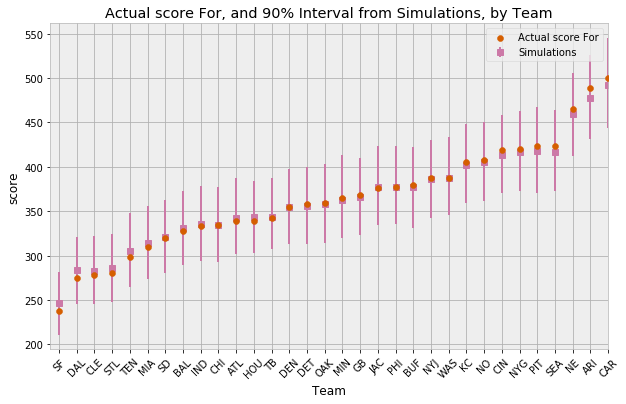

In [17]:
df_observed = create_season_table(df)
g = simuls_old.groupby('team')
season_hdis = pd.DataFrame({'for_lower': g.mf.quantile(.05),
                            'for_median': g.mf.median(),
                            'for_upper': g.mf.quantile(.95),
                            'against_lower': g.ma.quantile(.05),
                            'against_median': g.ma.median(),
                            'against_upper': g.ma.quantile(.95),
})
season_hdis = pd.merge(season_hdis, df_observed, left_index=True, right_on='team')
column_order = ['team', 'for_lower', 'mf', 'for_median', 'for_upper',
                'against_lower', 'ma', 'against_median', 'against_upper',]
season_hdis = season_hdis[column_order]
season_hdis['relative_upper'] = season_hdis.for_upper - season_hdis.for_median
season_hdis['relative_lower'] = season_hdis.for_median - season_hdis.for_lower
season_hdis = season_hdis.sort_index(by='mf')
season_hdis = season_hdis.reset_index()
season_hdis['x'] = season_hdis.index + .5
season_hdis

fig, axs = plt.subplots(figsize=(10,6))
axs.scatter(season_hdis.x, season_hdis.mf, c=sns.palettes.color_palette()[4], zorder = 10, label='Actual '+metric+' For')
axs.errorbar(season_hdis.x, season_hdis.for_median,
             yerr=(season_hdis[['relative_lower', 'relative_upper']].values).T,
             fmt='s', c=sns.palettes.color_palette()[5], label='Simulations')
axs.set_title('Actual '+metric+' For, and 90% Interval from Simulations, by Team')
axs.set_xlabel('Team')
axs.set_ylabel(metric)
axs.set_xlim(0, 20)
axs.legend()
_= axs.set_xticks(season_hdis.index + .5)
_= axs.set_xticklabels(season_hdis['team'].values, rotation=45)

